# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

# Simulating data

## Single df

### Creating

In [2]:
((20-5)+1) * ((9-5) +1) - (16 - 11)

75

In [ ]:
# dict_of_combs = {
    
    
#     's_5_20_5_9_16_80': [5,20,5,9,16],

#     's_13_28_5_9_16_80': [13,28,5,9,16],

#     's_19_34_5_9_16_80': [19,34,5,9,16],
#                  }

In [17]:
dict_of_combs = {


    'e': [20,14,4,7,4,7,2],
    
    'f': [20,14,4,7,4,7,2],
    'g': [20,14,4,7,4,7,2],
    
}

In [ ]:
i = 'g'
gdf_output = return_spatial_geo_df(

    n_x = dict_of_combs[i][0],  
    n_y = dict_of_combs[i][1],    
    spacing = 100, 

    treated_scope_x_start = dict_of_combs[i][2],
    treated_scope_x_end = dict_of_combs[i][3],
    treated_scope_y_start = dict_of_combs[i][4],
    treated_scope_y_end = dict_of_combs[i][5],
    treated_last_row_length = dict_of_combs[i][6],
   
    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 2,
    y_spatial_autocorelation_scope_x_end = 10,
    y_spatial_autocorelation_scope_y_start = 2,
    y_spatial_autocorelation_scope_y_end = 10,

    rho = 0.15,

    spatial_confounder_scope_x_start = 0,
    spatial_confounder_scope_x_end = 0,
    spatial_confounder_scope_y_start = 0,
    spatial_confounder_scope_y_end = 0,
    

    lambda_cs = 0.0,
    max_treatment_spillover_distance = 300,
    understimated_treatment_spillover_distance=None,
    overestimated_treatment_spillover_distance=None,
    
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2,
    y_ns_to_att_ratio = None)
print(len(gdf_output[gdf_output['T'] == 1]), len(gdf_output))#len(gdf_output[gdf_output['T_tot'] == 1]), len(gdf_output[gdf_output['T_tot'] == 0]))

14 280


In [95]:
dict_of_combs = {

    'a1': [6,10,1],

    'a2': [6,10,1.5],
    
    'a3': [6,10,2],
    
    'a4': [6,10,3.5],
    
    'a5': [6,10,4],

     'a6': [6,10,4.5],

    'a7': [6,10,5],
    
    'a8': [6,10,5.5],
    
    'a9': [6,10,6],
    
    'a10': [6,10,6.5],


    'b1': [7,11,1],

    'b2': [7,11,1.5],
    
    'b3': [7,11,2],
    
    'b4': [7,11,3.5],
    
    'b5': [7,11,4],

     'b6': [7,11,4.5],

    'b7': [7,11,5],
    
    'b8': [7,11,5.5],
    
    'b9': [7,11,6],
    
    'b10': [7,11,6.5],


    'c1': [8,12,1],

    'c2': [8,12,1.5],
    
    'c3': [8,12,2],
    
    'c4': [8,12,3.5],
    
    'c5': [8,12,4],

     'c6': [8,12,4.5],

    'c7': [8,12,5],
    
    'c8': [8,12,5.5],
    
    'c9': [8,12,6],
    
    'c10': [8,12,6.5],

        'd1': [9,13,1],

    'd2': [9,13,1.5],
    
    'd3': [9,13,2],
    
    'd4': [9,13,3.5],
    
    'd5': [9,13,4],

     'd6': [9,13,4.5],

    'd7': [9,13,5],
    
    'd8': [9,13,5.5],
    
    'd9': [9,13,6],
    
    'd10': [9,13,6.5],
    
}

In [96]:
i = 'd10'
gdf_output = return_spatial_geo_df(

    n_x = 20,  
    n_y = 15,    
    spacing = 100, 

    treated_scope_x_start = dict_of_combs[i][0],
    treated_scope_x_end = dict_of_combs[i][1],
    treated_scope_y_start = 6,
    treated_scope_y_end = 8,
    treated_last_row_length = None,
   
    ATT_target = 1.5,
    y_ns_to_att_ratio = dict_of_combs[i][2],

    y_spatial_autocorelation_scope_x_start = 2,
    y_spatial_autocorelation_scope_x_end = 10,
    y_spatial_autocorelation_scope_y_start = 2,
    y_spatial_autocorelation_scope_y_end = 10,

    rho = 0.15,

    spatial_confounder_scope_x_start = 0,
    spatial_confounder_scope_x_end = 0,
    spatial_confounder_scope_y_start = 0,
    spatial_confounder_scope_y_end = 0,
    

    lambda_cs = 0.0,
    max_treatment_spillover_distance = 400,
    understimated_treatment_spillover_distance=None,
    overestimated_treatment_spillover_distance=None,
    
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)
print(len(gdf_output[gdf_output['T'] == 1]), len(gdf_output))#len(gdf_output[gdf_output['T_tot'] == 1]), len(gdf_output[gdf_output['T_tot'] == 0]))

15 300


#### logic checks

In [97]:
gdf_output.isna().any().any()

np.False_

In [98]:
gdf_output[gdf_output['ODR_1'] == 1][['tau',
 'tau_base']]

,tau,tau_base
126,0.485286,0.525120
127,1.230556,1.331566
128,1.267708,1.371768
140,0.134859,0.145929
144,1.321255,1.429710
155,0.636915,0.689196
159,0.996881,1.078710
170,1.648909,1.784260
174,0.794962,0.860216
185,0.793652,0.858799


In [99]:
gdf_output[gdf_output['T']==1][['unit_id', 'Y_dep_var',
    'T','ODR_1',
    'ODR_2',
    'ODR_3',
    'ODR_4', 'Cont_T_N',]]

,unit_id,Y_dep_var,T,ODR_1,ODR_2,ODR_3,ODR_4,Cont_T_N
141,1141,9.555870,1,0,0,0,0,0.0
142,1142,14.422903,1,0,0,0,0,0.0
143,1143,14.352454,1,0,0,0,0,0.0
156,1156,11.730399,1,0,0,0,0,0.0
157,1157,14.602060,1,0,0,0,0,0.0
158,1158,13.455097,1,0,0,0,0,0.0
171,1171,12.194092,1,0,0,0,0,0.0
172,1172,10.998252,1,0,0,0,0,0.0
173,1173,12.342644,1,0,0,0,0,0.0
186,1186,13.749940,1,0,0,0,0,0.0


#### Numerical checks

In [100]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [101]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.47901873533458816)

In [102]:
gdf_output['Y_dep_var_ns'].mean()

np.float64(9.75)

In [103]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.4999999999999998)

In [104]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,T_tot_cat,ODR_1,ODR_2,...,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y_dep_var,Y_dep_var_ns
141,1141,POINT (900 600),900,600,1,-3.922438,1,treated_inner_ring,0,0,...,-1.591488,-0.203348,-2.366854,1.016727,1.016727,1.0,0.0,1.0,9.555870,7.826996
142,1142,POINT (900 700),900,700,1,1.399762,1,treated_inner_ring,0,0,...,0.916931,-0.381221,-0.223863,1.986451,1.986451,1.0,0.0,1.0,14.422903,12.506990
143,1143,POINT (900 800),900,800,1,2.878104,1,treated_inner_ring,0,0,...,0.215393,1.697718,-0.442071,1.593570,1.593570,1.0,0.0,1.0,14.352454,12.239309
156,1156,POINT (1000 600),1000,600,1,-0.903877,1,treated_inner_ring,0,0,...,-1.882296,1.165799,-0.130862,0.997727,0.997727,1.0,0.0,1.0,11.730399,9.950169
157,1157,POINT (1000 700),1000,700,1,2.407714,1,treated_inner_ring,0,0,...,0.142424,0.418993,1.876465,1.638658,1.638658,1.0,0.0,1.0,14.602060,12.704310
158,1158,POINT (1000 800),1000,800,1,0.179716,1,treated_inner_ring,0,0,...,-0.930896,-0.051633,1.451687,1.083265,1.083265,1.0,0.0,1.0,13.455097,11.421942
171,1171,POINT (1100 600),1100,600,1,0.230696,1,treated_inner_ring,0,0,...,-1.809969,0.809552,-0.600984,1.781262,1.781262,1.0,0.0,1.0,12.194092,12.194092
172,1172,POINT (1100 700),1100,700,1,-0.434199,1,treated_inner_ring,0,0,...,0.587008,-2.428783,0.516307,1.617463,1.617463,1.0,0.0,1.0,10.998252,10.998252
173,1173,POINT (1100 800),1100,800,1,0.534405,1,treated_inner_ring,0,0,...,0.200822,1.007788,-0.148383,1.994472,1.994472,1.0,0.0,1.0,12.342644,12.342644
186,1186,POINT (1200 600),1200,600,1,2.740137,1,treated_inner_ring,0,0,...,0.338909,0.408438,-0.034966,2.238315,2.238315,1.0,0.0,1.0,13.749940,13.749940


In [105]:
gdf_output.isna().any().any()

np.False_

In [106]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y_dep_var'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.3109', 'p-value simulated: 0.0010']

#### Visual checks

<Axes: >

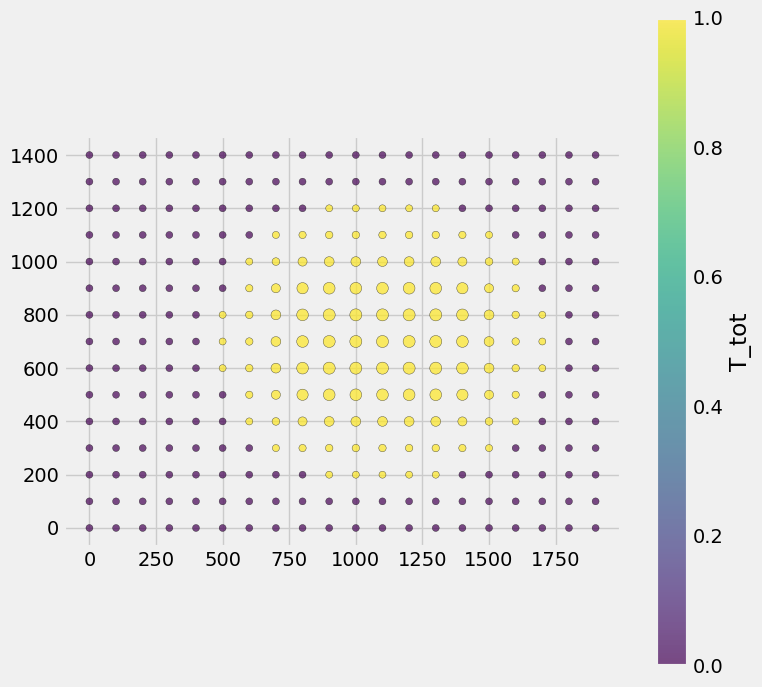

In [107]:

gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

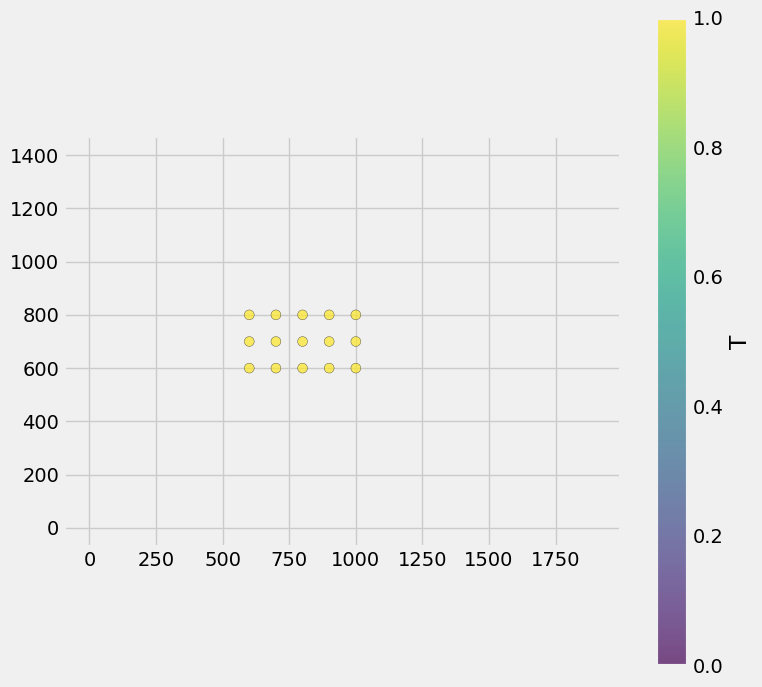

In [42]:
plot_gdf_points(gdf_output3, size_col='T',
    color_col='T')

<Axes: >

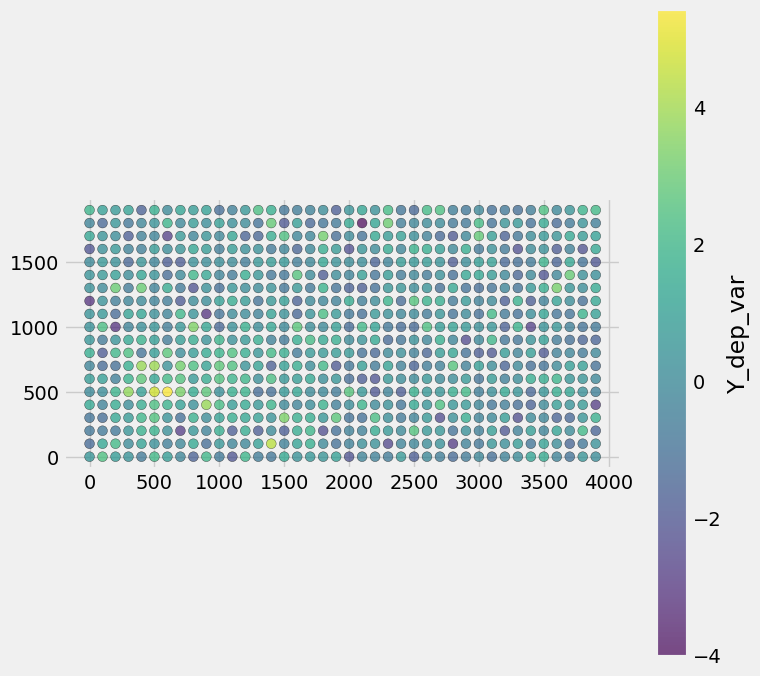

In [16]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y_dep_var')

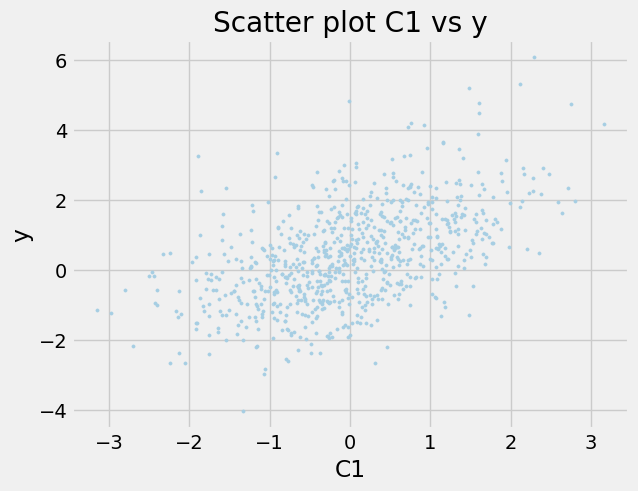

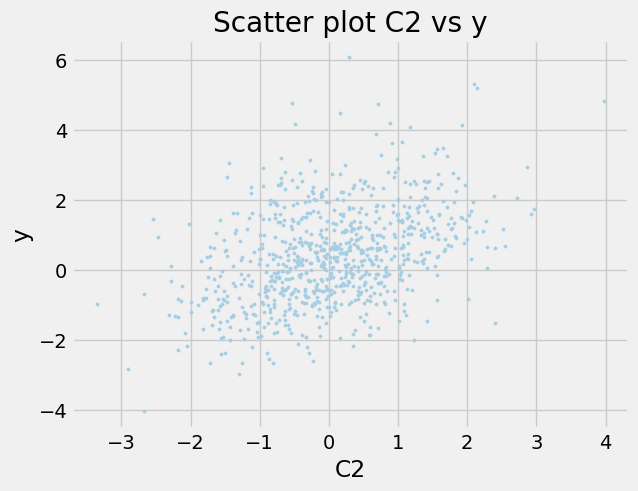

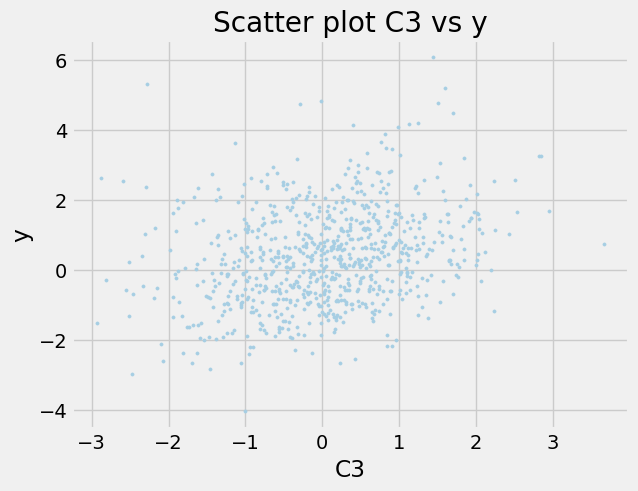

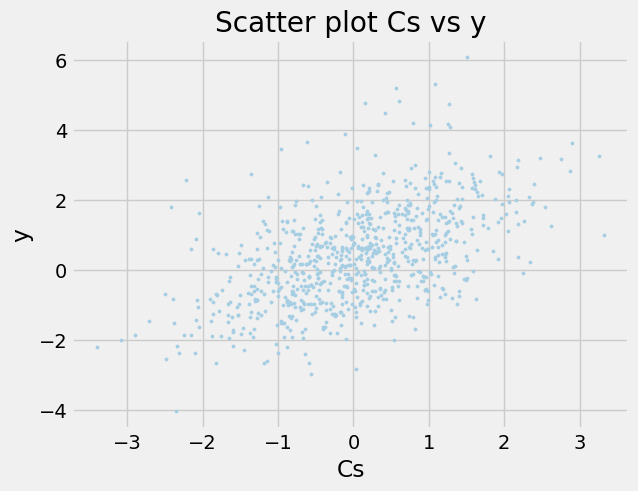

In [20]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y_dep_var", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [33]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y_dep_var"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_dep_var_ns"]
Y = gdf_output['Y_dep_var'].values

X_logit = sm.add_constant(X)

In [34]:
gdf_output4 = gdf_output.copy()
gdf_output4['treated'] = 'control'
gdf_output4.loc[(gdf_output4['spill'] == 1),'treated'] = 'inner_ring'
gdf_output4.loc[(gdf_output4['spill'] <= 0.924143)& (gdf_output4['spill'] >= 0.812214),'treated'] = 'outer_ring1'
gdf_output4.loc[(gdf_output4['spill'] <= 0.500001)& (gdf_output4['spill'] >= 0.356595),'treated'] = 'outer_ring2'
gdf_output4.loc[(gdf_output4['spill'] <= 0.111942)& (gdf_output4['spill'] >= 0.075857),'treated'] = 'outer_ring3'
gdf_output4.loc[(gdf_output4['spill'] <= 0.017744)& (gdf_output4['spill'] >= 0.006692),'treated'] = 'outer_ring4'
df_encoded = pd.get_dummies(gdf_output4, columns=['treated'], dtype=int)
T_mult = df_encoded[['treated_inner_ring',
    'treated_outer_ring1',
    'treated_outer_ring2',
    'treated_outer_ring3',
    'treated_outer_ring4']].to_numpy()
T_M= gdf_output4['treated'].values
T_M= T_M.astype(str)

##### Logit for T

In [35]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.368275
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  600
Model:                          Logit   Df Residuals:                      597
Method:                           MLE   Df Model:                            2
Date:                Sun, 24 May 2026   Pseudo R-squ.:                0.005287
Time:                        20:02:31   Log-Likelihood:                -220.97
converged:                       True   LL-Null:                       -222.14
Covariance Type:            nonrobust   LLR p-value:                    0.3090
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9832      0.126    -15.755      0.000      -2.230      -1.737
x1             0.0038      0.

##### Cross sectional linear difference in differences 

In [36]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Y_dep_var_ns   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.552
Method:                 Least Squares   F-statistic:                     246.8
Date:                Sun, 24 May 2026   Prob (F-statistic):          4.41e-104
Time:                        20:02:42   Log-Likelihood:                -787.26
No. Observations:                 600   AIC:                             1583.
Df Residuals:                     596   BIC:                             1600.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2456      0.039      6.241      0.0

In [37]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Y_dep_var_ns   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     226.3
Date:                Sun, 24 May 2026   Prob (F-statistic):           5.38e-98
Time:                        20:02:48   Log-Likelihood:                -801.38
No. Observations:                 600   AIC:                             1611.
Df Residuals:                     596   BIC:                             1628.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0953      0.049      1.945      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [ ]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y_dep_var",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

##### Basic causal forest

###### For T

In [ ]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

In [ ]:
ci_low_ate, ate, ci_high_ate

In [ ]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

###### For T tot

In [ ]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

#### Multiple T DML

In [ ]:
est = LinearDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)


In [ ]:
est.fit(Y, T_mult, X=X, 
        #W=W
        )

In [ ]:
te_pred = est.const_marginal_effect(X)
te_pred

In [ ]:
est2 = CausalForestDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

In [ ]:
te_pred2 = est2.const_marginal_effect(X)
te_pred2

#### S learner with multiple treatments

In [ ]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate, lb, ub = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df = pd.DataFrame(ite).rename(columns = {0:'inner_ring', 1:'outer_ring1', 
                                             2:'outer_ring2', 3:'outer_ring3',
                                             4:'outer_ring4'})
ITE_df['treated'] = T_M
ITE_df['ITE_real'] = gdf_output4['tau']
ITE_df['Y'] = Y

In [ ]:
ate, lb, ub

In [ ]:
ITE_df['treated'].unique()

In [ ]:
for i in ['outer_ring4', 'outer_ring3', 'outer_ring2', 'outer_ring1', 'inner_ring']:
    series_of_interest = ITE_df[ITE_df['treated']==i][i]
    att = series_of_interest.mean()
    se_att = (series_of_interest).std(ddof=1) / np.sqrt(len(series_of_interest))
    ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
    print(i, 
          [ci_low_att, att, ci_high_att], 
          ITE_df[ITE_df['treated']==i]['ITE_real'].mean())

In [ ]:
ITE_df

In [ ]:
ITE_df[ITE_df['treated']=='inner_ring']['ITE_real'].mean()

## Generating multiple df for simulations

### Data generation

#### Single test output

In [ ]:
# gdf_output = return_spatial_geo_df(n_x = 40,  
#     n_y = 20,    
#     spacing = 100, 

#     treated_scope_x_start = 10,
#     treated_scope_x_end = 24,
#     treated_scope_y_start = 7,
#     treated_scope_y_end = 13,

#     ATT_target = 1.5,

#     y_spatial_autocorelation_scope_x_start = 3,
#     y_spatial_autocorelation_scope_x_end = 25,
#     y_spatial_autocorelation_scope_y_start = 4,
#     y_spatial_autocorelation_scope_y_end = 11,

#     rho = 0.15,

#     spatial_confounder_scope_x_start = 12,
#     spatial_confounder_scope_x_end = 32,
#     spatial_confounder_scope_y_start = 2,
#     spatial_confounder_scope_y_end = 18,
    

#     lambda_cs = 0.2,
#     max_treatment_spillover_distance = 400,
#     understimated_treatment_spillover_distance=300,
#     overestimated_treatment_spillover_distance=500,
    
#     logistic_distance_decay = True,

#     nonspatial_confounders_contribution_to_Y=1.0,
#     spatial_confounder_contribution_to_Y=0.7,
    
#     epsilon_distribution_mean = 0.025,
#     epsilon_distribution_standard_error = 0.2)

#### Initial 15 samples for spatial predictors

In [ ]:
# list_of_rhos = []
# for i in np.arange(0.75, 0.000, -0.05):
#     list_of_rhos.append(i)
# len(list_of_rhos)

In [ ]:
# dict_of_output_gdf = {}
# for i in list_of_rhos:
#     single_gdf_output = return_spatial_geo_df(n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = 10,
#         treated_scope_x_end = 24,
#         treated_scope_y_start = 7,
#         treated_scope_y_end = 13,

#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,

#         rho = 0.15,

#         spatial_confounder_scope_x_start = 12,
#         spatial_confounder_scope_x_end = 32,
#         spatial_confounder_scope_y_start = 2,
#         spatial_confounder_scope_y_end = 18,
        

#         lambda_cs = 0.2,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=500,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
#     dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}'] = single_gdf_output2

In [ ]:
#len(['gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'])

#### 16 additional samples for spatial predictors

In [ ]:
# list_of_rhos = []
# for i in np.arange(0.775, 0.000, -0.05):
#     list_of_rhos.append(i)
# len(list_of_rhos)

In [ ]:
# dict_of_output_gdf = {}
# for i in list_of_rhos:
#     single_gdf_output = return_spatial_geo_df(n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = 10,
#         treated_scope_x_end = 24,
#         treated_scope_y_start = 7,
#         treated_scope_y_end = 13,

#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,

#         rho = 0.15,

#         spatial_confounder_scope_x_start = 12,
#         spatial_confounder_scope_x_end = 32,
#         spatial_confounder_scope_y_start = 2,
#         spatial_confounder_scope_y_end = 18,
        

#         lambda_cs = 0.2,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=500,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
#     dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}'] = single_gdf_output2

In [ ]:
#dict_of_output_gdf.keys()

#### 999 samples with spatial predictors and different rho

In [ ]:
# list_of_rhos2 = []
# for i in range(1, 1000, 1):
#     list_of_rhos2.append(i/1000)
# len(list_of_rhos2)

In [ ]:
# dict_of_output_gdf = {}
# for i in list_of_rhos2:
#     single_gdf_output = return_spatial_geo_df(n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = 10,
#         treated_scope_x_end = 24,
#         treated_scope_y_start = 7,
#         treated_scope_y_end = 13,

#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,

#         rho = i,

#         spatial_confounder_scope_x_start = 12,
#         spatial_confounder_scope_x_end = 32,
#         spatial_confounder_scope_y_start = 2,
#         spatial_confounder_scope_y_end = 18,

#         lambda_cs = 0.2,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=None,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['tau_base', 
#                                                           # 'spill','T_tot',
#                         'distance_to_treatment',
#                         'decay','C3',
#                         'Cs','geometry',
#                         'propensity',
#                         'T_tot_cat_underestim']).copy()
#     dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}_nspred'] = single_gdf_output2

In [ ]:
# len(dict_of_output_gdf.keys())

#### 1000 samples without spatial predictors and different treated size

In [ ]:
# dict_of_combs = {}

# el3 = 5  

# for el1 in range(5, 20):          
#     el2 = el1 + 15                

#     for el4 in range(9, 15):      
#         for el5 in range(1, 17): 

#             y = ((el2 - el1) + 1) * ((el4 - el3) + 1) - (16 - el5)

#             # ograniczenie:
#             # jeśli y == 80, to el5 musi być równe 16
#             if y == 80 and el5 != 16:
#                 continue

#             key = f"s_{el1}_{el2}_{el3}_{el4}_{el5}_{y}"

#             dict_of_combs[key] = [el1, el2, el3, el4, el5]

In [ ]:
# for k in [k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(65, 80))]:
#     dict_of_combs.pop(k, None)

In [ ]:
#len(dict_of_combs.keys())

1215

In [ ]:
#len([k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(80, 100))] + [k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(0, 61))])

1215

In [7]:
# temp_list = ([k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(65, 99,5))  and dict_of_combs[k][1]==28] 
#     + [k for k in dict_of_combs.keys() if int(k[-2:]) in list(range(0, 61,5))  and dict_of_combs[k][1]==28])
# temp_list

In [ ]:
# dict_of_output_gdf = {}
# for i in temp_list:
#     single_gdf_output = return_spatial_geo_df(
        
#         n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = dict_of_combs[i][0],
#         treated_scope_x_end = dict_of_combs[i][1],
#         treated_scope_y_start = dict_of_combs[i][2],
#         treated_scope_y_end = dict_of_combs[i][3],
#         treated_last_row_length = dict_of_combs[i][4],


#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,


#         rho = 0.2,
#         spatial_confounder_scope_x_start = 0,
#         spatial_confounder_scope_x_end = 0,
#         spatial_confounder_scope_y_start = 0,
#         spatial_confounder_scope_y_end = 0,
        
#         lambda_cs = 0.0,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=None,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['tau_base', 
#                                                           # 'spill','T_tot',
#                         'distance_to_treatment',
#                         'decay','C3',
#                         'Cs','geometry',
#                         'propensity',
#                         'T_tot_cat_underestim']).copy()
#     dict_of_output_gdf[i] = single_gdf_output2

In [8]:
#dict_of_output_gdf['s_13_28_5_9_16_80']

#### 1000 samples with different sample size

In [ ]:
dict_of_combs = {

    'a': [12,10,4,6,4,5, None],
    'b': [16,10,4,7,4,5,None],
    'c': [20,10,4,8,4,5,None],
    'd': [20,12,4,7,4,6,None],
    'e': [20,14,4,7,4,7,2],
    
    'f': [20,16,4,7,4,7,None],
    'g': [20,18,4,8,4,7,3],
    'h': [20,20,4,8,4,7,None],
    'i': [22,20,4,9,4,7,4],
    'j': [24,20,4,9,4,7,6],
    'k': [26,20,4,10,4,7,5],

    'l': [28,20,4,11,4,7,4],
    'm': [30,20,4,13,4,6,None],
    'n': [32,20,4,13,4,7,2],
    'o': [34,20,4,13,4,7,4],
    'p': [36,20,4,13,4,7,6],

    'q': [38,20,4,13,4,7,8],
    'r': [40,20,4,13,4,7,10],

    
}

In [41]:
dict_of_combs = {

    'a': [12,10,4,6,4,5, None],
    'b': [16,10,4,7,4,5,None],
    'c': [20,10,4,8,4,5,None],
    'd': [20,12,4,7,4,6,None],
    'e': [20,14,4,7,4,7,2],
    
    'f': [20,16,4,7,4,7,None],
    'g': [20,18,4,8,4,7,3],
    'h': [20,20,4,8,4,7,None],
    'i': [22,20,4,9,4,7,4],
    'j': [24,20,4,9,4,7,6],

    'a1': [12,10,4,6,4,5, None],
    'b1': [16,10,4,7,4,5,None],
    'c1': [20,10,4,8,4,5,None],
    'd1': [20,12,4,7,4,6,None],
    'e1': [20,14,4,7,4,7,2],
    
    'f1': [20,16,4,7,4,7,None],
    'g1': [20,18,4,8,4,7,3],
    'h1': [20,20,4,8,4,7,None],
    'i1': [22,20,4,9,4,7,4],
    'j1': [24,20,4,9,4,7,6],
   
     
    'a2': [12,10,4,6,4,5, None],
    'b2': [16,10,4,7,4,5,None],
    'c2': [20,10,4,8,4,5,None],
    'd2': [20,12,4,7,4,6,None],
    'e2': [20,14,4,7,4,7,2],
    
    'f2': [20,16,4,7,4,7,None],
    'g2': [20,18,4,8,4,7,3],
    'h2': [20,20,4,8,4,7,None],
    'i2': [22,20,4,9,4,7,4],
    'j2': [24,20,4,9,4,7,6],
    

    'a3': [12,10,4,6,4,5, None],
    'b3': [16,10,4,7,4,5,None],
    'c3': [20,10,4,8,4,5,None],
    'd3': [20,12,4,7,4,6,None],
    'e3': [20,14,4,7,4,7,2],
    
    'f3': [20,16,4,7,4,7,None],
    'g3': [20,18,4,8,4,7,3],
    'h3': [20,20,4,8,4,7,None],
    'i3': [22,20,4,9,4,7,4],
    'j3': [24,20,4,9,4,7,6],

    'a4': [12,10,4,6,4,5, None],
    'b4': [16,10,4,7,4,5,None],
    'c4': [20,10,4,8,4,5,None],
    'd4': [20,12,4,7,4,6,None],
    'e4': [20,14,4,7,4,7,2],
    
    'f4': [20,16,4,7,4,7,None],
    'g4': [20,18,4,8,4,7,3],
    'h4': [20,20,4,8,4,7,None],
    'i4': [22,20,4,9,4,7,4],
    'j4': [24,20,4,9,4,7,6],
   
     
    'a5': [12,10,4,6,4,5, None],
    'b5': [16,10,4,7,4,5,None],
    'c5': [20,10,4,8,4,5,None],
    'd5': [20,12,4,7,4,6,None],
    'e5': [20,14,4,7,4,7,2],
    
    'f5': [20,16,4,7,4,7,None],
    'g5': [20,18,4,8,4,7,3],
    'h5': [20,20,4,8,4,7,None],
    'i5': [22,20,4,9,4,7,4],
    'j5': [24,20,4,9,4,7,6],


      'a0': [12,10,4,6,4,5, None],
    'b0': [16,10,4,7,4,5,None],
    'c0': [20,10,4,8,4,5,None],
    'd0': [20,12,4,7,4,6,None],
    'e0': [20,14,4,7,4,7,2],
    
    'f0': [20,16,4,7,4,7,None],
    'g0': [20,18,4,8,4,7,3],
    'h0': [20,20,4,8,4,7,None],
    'i0': [22,20,4,9,4,7,4],
    'j0': [24,20,4,9,4,7,6],

    'a10': [12,10,4,6,4,5, None],
    'b10': [16,10,4,7,4,5,None],
    'c10': [20,10,4,8,4,5,None],
    'd10': [20,12,4,7,4,6,None],
    'e10': [20,14,4,7,4,7,2],
    
    'f10': [20,16,4,7,4,7,None],
    'g10': [20,18,4,8,4,7,3],
    'h10': [20,20,4,8,4,7,None],
    'i10': [22,20,4,9,4,7,4],
    'j10': [24,20,4,9,4,7,6],
   
     
    'a20': [12,10,4,6,4,5, None],
    'b20': [16,10,4,7,4,5,None],
    'c20': [20,10,4,8,4,5,None],
    'd20': [20,12,4,7,4,6,None],
    'e20': [20,14,4,7,4,7,2],
    
    'f20': [20,16,4,7,4,7,None],
    'g20': [20,18,4,8,4,7,3],
    'h20': [20,20,4,8,4,7,None],
    'i20': [22,20,4,9,4,7,4],
    'j20': [24,20,4,9,4,7,6],
    

    'a30': [12,10,4,6,4,5, None],
    'b30': [16,10,4,7,4,5,None],
    'c30': [20,10,4,8,4,5,None],
    'd30': [20,12,4,7,4,6,None],
    'e30': [20,14,4,7,4,7,2],
    
    'f30': [20,16,4,7,4,7,None],
    'g30': [20,18,4,8,4,7,3],
    'h30': [20,20,4,8,4,7,None],
    'i30': [22,20,4,9,4,7,4],
    'j30': [24,20,4,9,4,7,6],

    'a40': [12,10,4,6,4,5, None],
    'b40': [16,10,4,7,4,5,None],
    'c40': [20,10,4,8,4,5,None],
    'd40': [20,12,4,7,4,6,None],
    'e40': [20,14,4,7,4,7,2],
    
    'f40': [20,16,4,7,4,7,None],
    'g40': [20,18,4,8,4,7,3],
    'h40': [20,20,4,8,4,7,None],
    'i40': [22,20,4,9,4,7,4],
    'j40': [24,20,4,9,4,7,6],
   
     
    'a50': [12,10,4,6,4,5, None],
    'b50': [16,10,4,7,4,5,None],
    'c50': [20,10,4,8,4,5,None],
    'd50': [20,12,4,7,4,6,None],
    'e50': [20,14,4,7,4,7,2],
    
    'f50': [20,16,4,7,4,7,None],
    'g50': [20,18,4,8,4,7,3],
    'h50': [20,20,4,8,4,7,None],
    'i50': [22,20,4,9,4,7,4],
    'j50': [24,20,4,9,4,7,6],
}




In [ ]:
dict_of_output_gdf = {}
for i in dict_of_combs.keys():
    single_gdf_output = return_spatial_geo_df(
        
        n_x = dict_of_combs[i][0],  
        n_y = dict_of_combs[i][1],    
        spacing = 100, 

        treated_scope_x_start = dict_of_combs[i][2],
        treated_scope_x_end = dict_of_combs[i][3],
        treated_scope_y_start = dict_of_combs[i][4],
        treated_scope_y_end = dict_of_combs[i][5],
        treated_last_row_length = dict_of_combs[i][6],


        ATT_target = 1.5,

        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,


        rho = 0.2,
        spatial_confounder_scope_x_start = 0,
        spatial_confounder_scope_x_end = 0,
        spatial_confounder_scope_y_start = 0,
        spatial_confounder_scope_y_end = 0,
        
        lambda_cs = 0.0,
        max_treatment_spillover_distance = 300,
        understimated_treatment_spillover_distance=300,
        overestimated_treatment_spillover_distance=None,
        
        logistic_distance_decay = True,

        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2,
         y_ns_to_att_ratio = None)
    single_gdf_output2 = single_gdf_output.drop(columns = ['tau_base', 
                                                          # 'spill','T_tot',
                        'distance_to_treatment',
                        'decay','C3',
                        'Cs','geometry',
                        'propensity',
                        'T_tot_cat_underestim']).copy()
    ik = str(dict_of_combs[i][0]*dict_of_combs[i][1])
    dict_of_output_gdf[i] = single_gdf_output2

In [49]:
len(dict_of_output_gdf.keys())

120

#### samples with different treatment effect

In [108]:
dict_of_combs = {

    'a1': [6,10,1],

    'a2': [6,10,1.5],
    
    'a3': [6,10,2],
    
    'a4': [6,10,3.5],
    
    'a5': [6,10,4],

     'a6': [6,10,4.5],

    'a7': [6,10,5],
    
    'a8': [6,10,5.5],
    
    'a9': [6,10,6],
    
    'a10': [6,10,6.5],


    'b1': [7,11,1],

    'b2': [7,11,1.5],
    
    'b3': [7,11,2],
    
    'b4': [7,11,3.5],
    
    'b5': [7,11,4],

     'b6': [7,11,4.5],

    'b7': [7,11,5],
    
    'b8': [7,11,5.5],
    
    'b9': [7,11,6],
    
    'b10': [7,11,6.5],


    'c1': [8,12,1],

    'c2': [8,12,1.5],
    
    'c3': [8,12,2],
    
    'c4': [8,12,3.5],
    
    'c5': [8,12,4],

     'c6': [8,12,4.5],

    'c7': [8,12,5],
    
    'c8': [8,12,5.5],
    
    'c9': [8,12,6],
    
    'c10': [8,12,6.5],

        'd1': [9,13,1],

    'd2': [9,13,1.5],
    
    'd3': [9,13,2],
    
    'd4': [9,13,3.5],
    
    'd5': [9,13,4],

     'd6': [9,13,4.5],

    'd7': [9,13,5],
    
    'd8': [9,13,5.5],
    
    'd9': [9,13,6],
    
    'd10': [9,13,6.5],
    
}

In [110]:
dict_of_output_gdf = {}
for i in dict_of_combs.keys():
    single_gdf_output = return_spatial_geo_df(

        n_x = 20,  
        n_y = 15,    
        spacing = 100, 

        treated_scope_x_start = dict_of_combs[i][0],
        treated_scope_x_end = dict_of_combs[i][1],
        treated_scope_y_start = 6,
        treated_scope_y_end = 8,
        treated_last_row_length = None,
    
        ATT_target = 1.5,
        y_ns_to_att_ratio = dict_of_combs[i][2],

        y_spatial_autocorelation_scope_x_start = 2,
        y_spatial_autocorelation_scope_x_end = 10,
        y_spatial_autocorelation_scope_y_start = 2,
        y_spatial_autocorelation_scope_y_end = 10,

        rho = 0.15,

        spatial_confounder_scope_x_start = 0,
        spatial_confounder_scope_x_end = 0,
        spatial_confounder_scope_y_start = 0,
        spatial_confounder_scope_y_end = 0,
        

        lambda_cs = 0.0,
        max_treatment_spillover_distance = 400,
        understimated_treatment_spillover_distance=300,
        overestimated_treatment_spillover_distance=None,
        
        logistic_distance_decay = True,

        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    
    single_gdf_output2 = single_gdf_output.drop(columns = ['tau_base', 
                                                          # 'spill','T_tot',
                        'distance_to_treatment',
                        'decay','C3',
                        'Cs','geometry',
                        'propensity',
                        #'T_tot_cat_underestim'
                        ]).copy()
    dict_of_output_gdf[i] = single_gdf_output2

# Data saving

In [111]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [112]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data_effect_size.sqlite')
cursor = conn.cursor()

In [113]:
repo_path_r_string

'C:\\Users\\andre\\Desktop\\IDS\\02_VS_code\\03_comparing_causal_ML_models_with_spatial_effects'

In [114]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_sql(
    k,
    conn,
    if_exists="replace",
    index=False
)


In [ ]:
# sqlite_path = repo_path_r_string + r"\03_simulated_data\simulated_data.sqlite"

# for k, gdf in dict_of_output_gdf.items():

#     gdf.to_file(
#         sqlite_path,
#         layer=k,
#         driver="SQLite"
#     )

In [115]:
conn.close()